In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, GRU, Dense, RepeatVector, TimeDistributed, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from tensorflow.keras.regularizers import l1_l2
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import AdamW

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# ✅ 모델 하이퍼파라미터 설정
latent_dim = 15
dropout_rate = 0.2
batchnorm = True  # BatchNormalization 사용 여부
epochs = 100
patience = 5
batch_size = 32
kernel_regularizer = True  # L1_L2 Regularizer 사용 여부


In [89]:
csv_logger=CSVLogger("training_log.csv",append=False)

In [90]:
sys.stdout.flush()

In [91]:
# Load dataset
df = pd.read_csv("df_merged_with_category_scores.csv")

# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter data up to 2024-11-29 and drop rows with missing values
df = df[df['date'] <= '2024-11-29'].dropna()

# Sort by date
df = df.sort_values(by='date')

# Drop non-numeric columns
df = df.drop(columns=["month_key"], errors='ignore')

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.drop(columns=['date']))

In [92]:
# Prepare rolling window data (last 30 days for each date)
window_size = 30
X = []
dates = []
for i in range(window_size, len(df)):
    X.append(scaled_data[i - window_size:i])
    dates.append(df.iloc[i]['date'])
X = np.array(X)  # Shape: (샘플 수, 30일, 피처 수)

In [93]:
# Input Layer
input_layer = Input(shape=(X.shape[1], X.shape[2]))

# Encoder
encoded = GRU(64, activation='relu', return_sequences=True, kernel_regularizer=l1_l2(1e-5, 1e-4))(input_layer)
if batchnorm:
    encoded = BatchNormalization()(encoded)
encoded = Dropout(dropout_rate)(encoded)
encoded = GRU(64, activation='relu', return_sequences=False, kernel_regularizer=l1_l2(1e-5, 1e-4) if kernel_regularizer else None)(encoded)
encoded = Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = RepeatVector(30)(encoded)
decoded = GRU(64, activation='relu', return_sequences=True)(decoded)
decoded = GRU(64, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(X.shape[2], activation='sigmoid'))(decoded)

# Autoencoder Model
autoencoder = keras.Model(input_layer, decoded)
# ✅ AdamW 옵티마이저 설정
optimizer = AdamW(learning_rate=0.001, weight_decay=1e-4)

# ✅ 모델 컴파일
autoencoder.compile(optimizer=optimizer, loss='mse')
# Early Stopping 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)



In [94]:
# Train Autoencoder
autoencoder.fit(X, X, epochs=epochs, batch_size=batch_size, shuffle=True, validation_split=0.1, callbacks=[early_stopping, csv_logger], verbose=1)

df_log=pd.read_csv("training_log.csv")
print(df_log.head())

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - loss: 0.0606 - val_loss: 0.0708
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0182 - val_loss: 0.0638
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0110 - val_loss: 0.0521
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0088 - val_loss: 0.0447
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - loss: 0.0081 - val_loss: 0.0489
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0074 - val_loss: 0.0265
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0066 - val_loss: 0.0267
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0064 - val_loss: 0.0183
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0063 - val_loss: 0.0168
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0061 - val_loss: 0.0180
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0063 - val_loss: 0.0177
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [95]:
# Extract latent features
encoder = keras.Model(input_layer, encoded)
latent_features = encoder.predict(X)

# Convert latent features to DataFrame
latent_df = pd.DataFrame(latent_features, columns=[f'latent_{i}' for i in range(latent_dim)])
latent_df['date'] = dates

# ✅ 하이퍼파라미터 추가
hyperparams = {
    "latent_dim": latent_dim,
    "dropout_rate": dropout_rate,
    "batchnorm": batchnorm,
    "epochs": epochs,
    "early_stopping_patience": patience,
    "batch_size": batch_size,
    "kernel_regularizer": kernel_regularizer
}
for key, value in hyperparams.items():
    latent_df[key] = value  # 모든 행에 동일한 하이퍼파라미터 값 추가

# Save the latent features
latent_df.to_csv("latent_features_dropout_batchnorm_l1_l2.csv", index=False)

# Display first few rows
print(latent_df.head())  # 상위 5개 행 출력

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
   latent_0  latent_1  latent_2  latent_3  latent_4  latent_5  latent_6  \
0  2.758159  1.887641  3.182884  4.286491  7.303472  0.125243       0.0   
1  2.753183  1.893128  3.176241  4.290176  7.306885  0.126301       0.0   
2  2.752420  1.889801  3.171801  4.288112  7.305984  0.133525       0.0   
3  2.750343  1.887092  3.164987  4.287573  7.306919  0.135075       0.0   
4  2.749890  1.883391  3.156540  4.288564  7.307486  0.131305       0.0   

   latent_7  latent_8  latent_9  ...  latent_14  latent_15       date  \
0       0.0  3.361044  0.131351  ...   2.435267        0.0 2014-02-17   
1       0.0  3.361137  0.128200  ...   2.430802        0.0 2014-02-18   
2       0.0  3.361128  0.122331  ...   2.428281        0.0 2014-02-19   
3       0.0  3.361056  0.118164  ...   2.427145        0.0 2014-02-20   
4       0.0  3.361727  0.119358  ...   2.430554        0.0 2014-02-21   

   latent_dim  dropout_rate  batchnorm epochs  early_stopping_patience

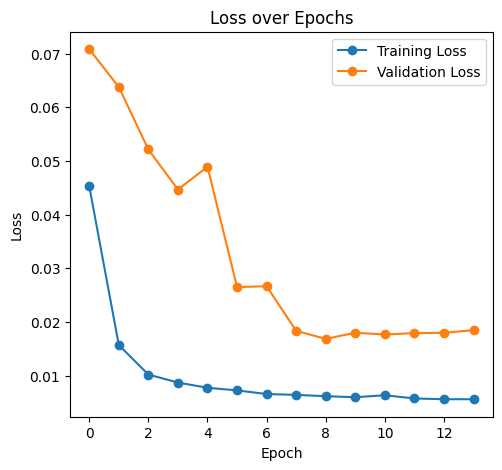

In [96]:
# ✅ 학습 로그 불러오기
df_log = pd.read_csv("training_log.csv")

# ✅ 그래프 그리기
plt.figure(figsize=(12, 5))

# 🔹 1. 손실 그래프 (Loss)
plt.subplot(1, 2, 1)
plt.plot(df_log["epoch"], df_log["loss"], label="Training Loss", marker="o")
plt.plot(df_log["epoch"], df_log["val_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.show()
